## Dataset Overview

We are going to work with the **FashionMNIST** dataset. This dataset includes:

- **Training Set**: 60,000 examples
- **Test Set**: 10,000 examples

In [27]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torch import optim
from tqdm.notebook import tqdm

Setting Device

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device
IMG_SIZE = 32
C_IN = 1 
LR = 2e-5
EPOCHS = 10

In [11]:
torch.cuda.get_device_name(0)

'NVIDIA GeForce RTX 5060 Laptop GPU'

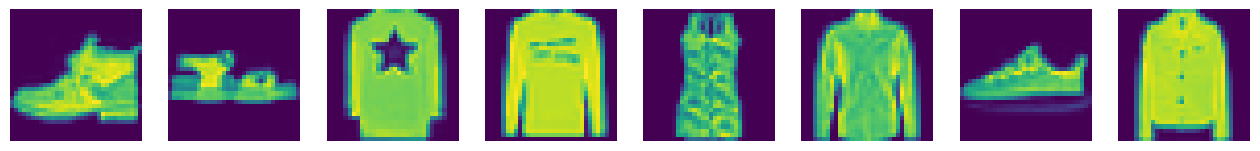

In [12]:
temp_transform = transforms.Compose([
            transforms.Resize((32, 32)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
])

def plot_images(images):
    fig, axes = plt.subplots(1, 8, figsize=(16, 2))
    for ax, img in zip(axes, images):
        ax.imshow(img.permute(1, 2, 0))
        ax.axis("off")

    plt.show()


data = torchvision.datasets.FashionMNIST(root = ".", download = True, train = True, transform = temp_transform)
dataloader = DataLoader(data, batch_size = 32, shuffle=True)
images, labels = next(iter(dataloader))

plot_images(images[:8])

## GANs (Generative Adversarial Networks) 

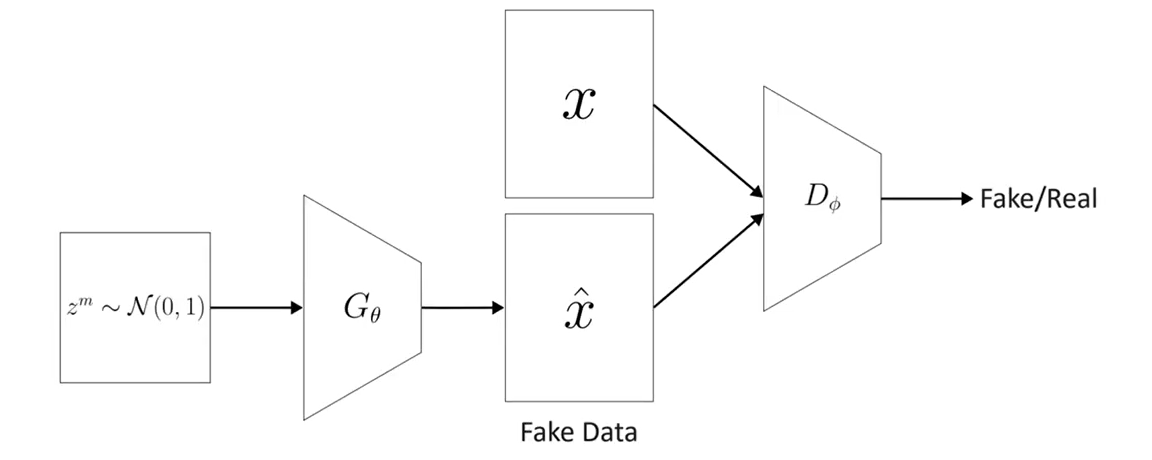
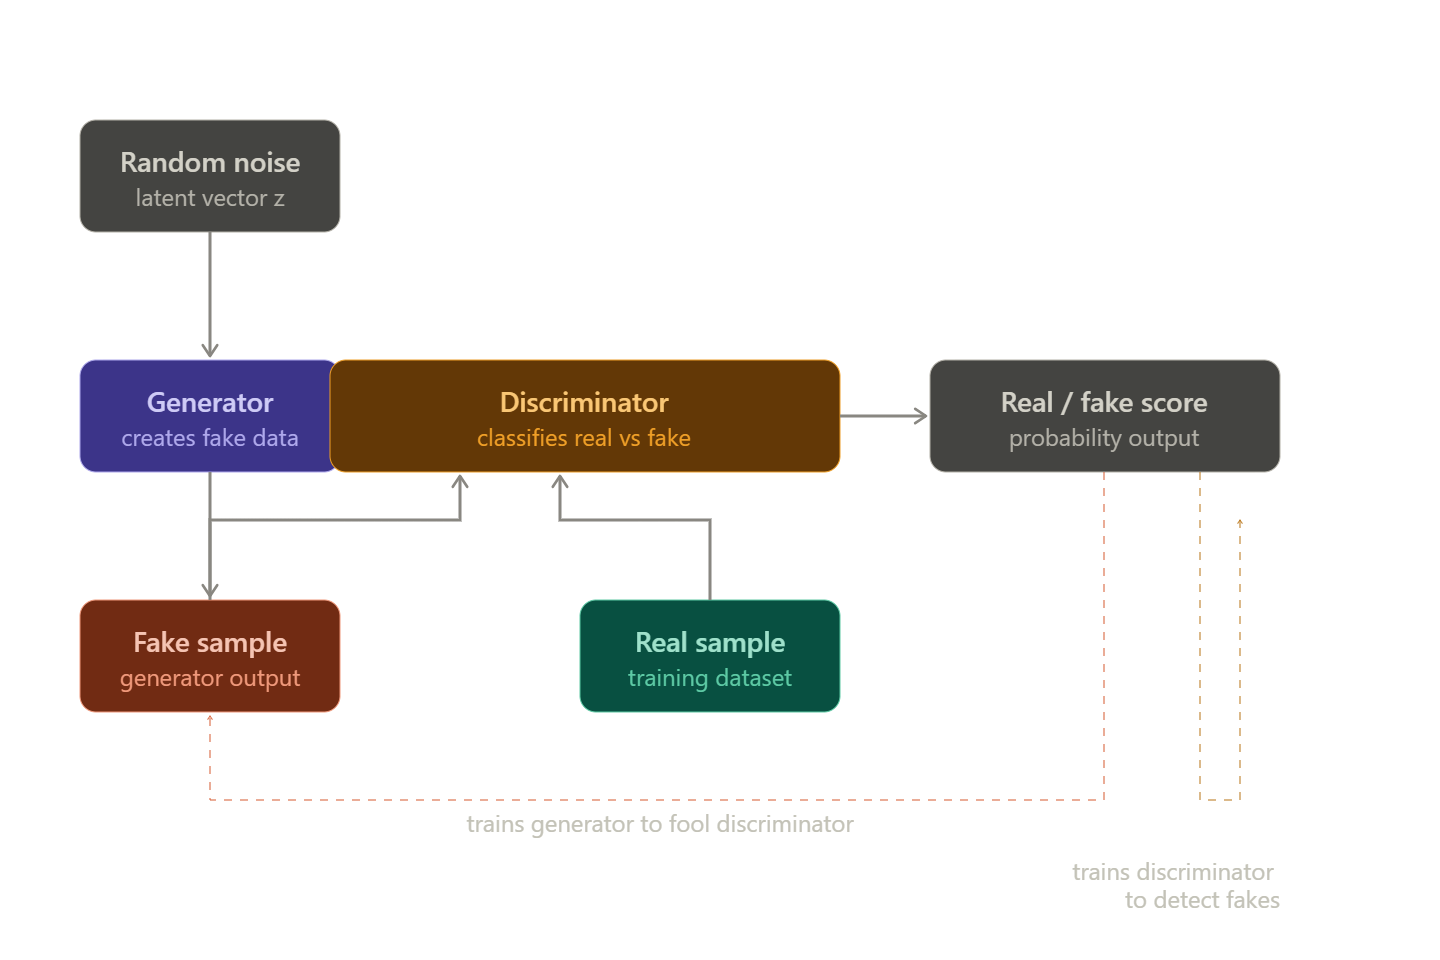

GANs' architecture includes Generator and Discriminator. The Discriminator section is a kind of Binary-Classifier that identifies whether the input image is Real or Fake. On the other hand, the Generator attempts to create synthetic images from random noise ($\hat{x}$) such that the Discriminator cannot distinguish them from the real images. Thus, the standard loss for GAN is the following min-max loss:

$$
\min_{\theta_g} \max_{\theta_d}
E_{x \sim p_{data}}[\log(D_{\theta_d}(x))]
+
E_{\hat{x} \sim p(\hat{x})}
[\log(1 - D_{\theta_d}(G_{\theta_g}(\hat{x})))]
$$

We optimize the loss function by alternating between the following objectives for the Discriminator and the Generator:

+ Discriminator's objective:
  $$
  \max_{\theta_d}
  E_{x \sim p_{data}}[\log(D_{\theta_d}(x))]
  +
  E_{\hat{x} \sim p(\hat{x})}
  [\log(1 - D_{\theta_d}(G_{\theta_g}(\hat{x})))]
  $$

+ Generator's objective:
  $$
  \min_{\theta_g}
  E_{\hat{x} \sim p(\hat{x})}
  [\log(1 - D_{\theta_d}(G_{\theta_g}(\hat{x})))]
  $$

In [ ]:
class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=1, feature_g=64):
        super(Generator, self).__init__()
        self.network = nn.Sequential(
            nn.ConvTranspose2d(z_dim, feature_g * 4, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(feature_g * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(feature_g * 4, feature_g * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(feature_g * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(feature_g * 2, feature_g, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(feature_g),
            nn.ReLU(True),
            nn.ConvTranspose2d(feature_g, img_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
        )
    def forward(self, z):
        return self.network(z)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, img_channels=1, feature_d=64):
        super(Discriminator, self).__init__()
        self.network = nn.Sequential(
            nn.Conv2d(img_channels, feature_d, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace = True),
            nn.Conv2d(feature_d, feature_d * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(feature_d * 2),
            nn.LeakyReLU(0.2, inplace = True),
            nn.Conv2d(feature_d * 2, feature_d * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(feature_d * 4),
            nn.LeakyReLU(0.2, inplace = True),
            nn.Conv2d(feature_d * 4, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, img):
        real_or_fake = self.network(img)
        return real_or_fake.view(-1)

In [50]:
class GANManager():
    def __init__(self, z_dim=100, img_channels=1, feature_g=64, feature_d=64, lr=2e-5, device='cpu'):
        self.device = device
        self.z_dim = z_dim
        self.generator = Generator(z_dim=z_dim, img_channels=img_channels, feature_g=feature_g).to(device)
        self.discriminator = Discriminator(img_channels=img_channels, feature_d=feature_d).to(device)

        self.optimizer_G = optim.Adam(self.generator.parameters(), lr=lr, betas=(0.5, 0.999))
        self.optimizer_D = optim.Adam(self.discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

        self.criterion = nn.BCELoss()

    def train(self, dataloader, **kwargs):
        history = dict(g_loss=[], d_loss=[])

        for epoch in range(EPOCHS):
            total_g_loss = []
            total_d_loss = []

            for i, (batch_x, _) in enumerate(tqdm(dataloader)):
                batch_size = batch_x.size(0)
                batch_x = batch_x.to(self.device)

                real_labels = torch.ones(batch_size, device=self.device)
                fake_labels = torch.zeros(batch_size, device=self.device)

                self.discriminator.zero_grad()

                outputs_real = self.discriminator(batch_x)
                d_loss_real = self.criterion(outputs_real, real_labels)

                z = torch.randn(batch_size, self.z_dim, 1, 1, device=self.device)
                fake_images = self.generator(z)

                outputs_fake = self.discriminator(fake_images.detach())
                d_loss_fake = self.criterion(outputs_fake, fake_labels)

                discriminator_loss = d_loss_real + d_loss_fake
                discriminator_loss.backward()
                self.optimizer_D.step()

                self.generator.zero_grad()

                z = torch.randn(batch_size, self.z_dim, 1, 1, device=self.device)
                fake_images = self.generator(z)

                outputs = self.discriminator(fake_images)
                generator_loss = self.criterion(outputs, real_labels)

                generator_loss.backward()
                self.optimizer_G.step()

                total_g_loss.append(generator_loss.item())
                total_d_loss.append(discriminator_loss.item())

            mean_d_loss = np.mean(total_d_loss)
            mean_g_loss = np.mean(total_g_loss)

            print(
                "[Epoch: %d/%d] [D loss: %.4f] [G loss: %.4f]"
                % (epoch + 1, EPOCHS, mean_d_loss, mean_g_loss)
            )

            self.sample(8, plot=True)

            history['d_loss'].append(mean_d_loss)
            history['g_loss'].append(mean_g_loss)

        return history

    def sample(self, n, plot=True):
        z = torch.randn(n, self.z_dim, 1, 1, device=self.device)

        with torch.no_grad():
            gen_imgs = self.generator(z)

            if plot:
                plot_images(gen_imgs)

            return gen_imgs

  0%|          | 0/1875 [00:00<?, ?it/s]

[Epoch: 1/10] [D loss: 0.0441] [G loss: 5.4498]


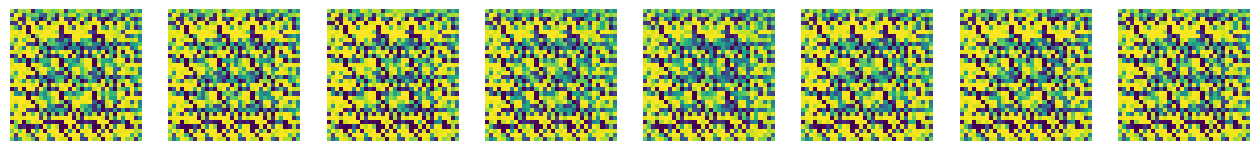

  0%|          | 0/1875 [00:00<?, ?it/s]

[Epoch: 2/10] [D loss: 0.0430] [G loss: 4.9220]


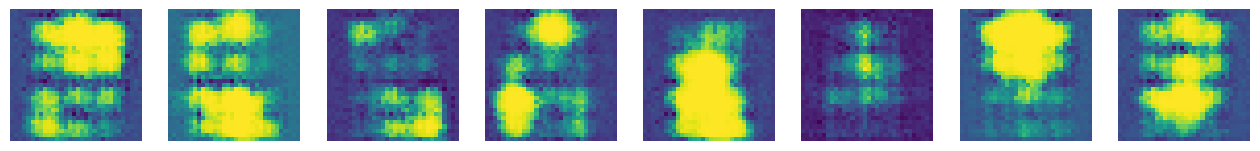

  0%|          | 0/1875 [00:00<?, ?it/s]

[Epoch: 3/10] [D loss: 0.0278] [G loss: 5.5805]


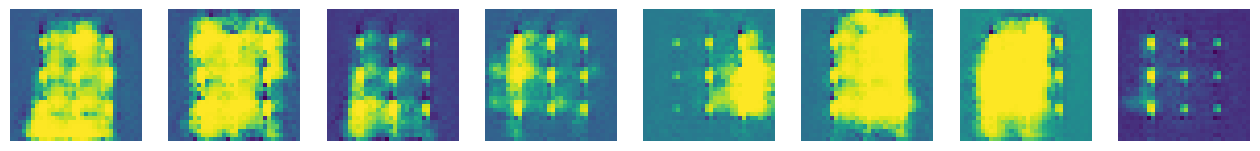

  0%|          | 0/1875 [00:00<?, ?it/s]

[Epoch: 4/10] [D loss: 0.0298] [G loss: 5.4406]


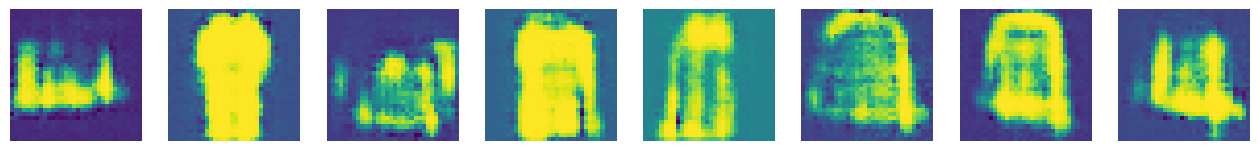

  0%|          | 0/1875 [00:00<?, ?it/s]

[Epoch: 5/10] [D loss: 0.0535] [G loss: 4.8358]


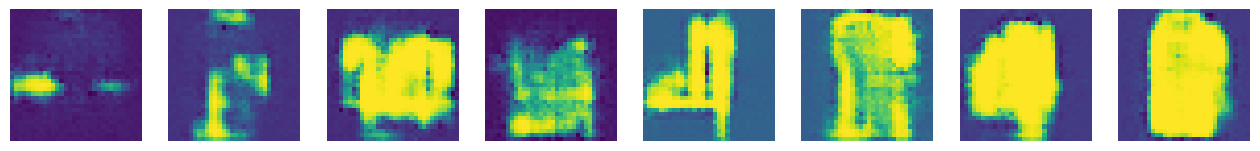

  0%|          | 0/1875 [00:00<?, ?it/s]

[Epoch: 6/10] [D loss: 0.0594] [G loss: 4.7259]


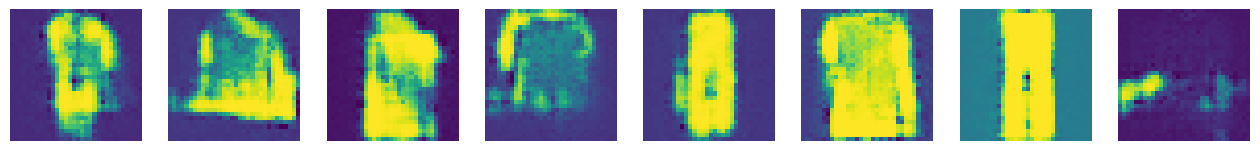

  0%|          | 0/1875 [00:00<?, ?it/s]

[Epoch: 7/10] [D loss: 0.0675] [G loss: 4.6060]


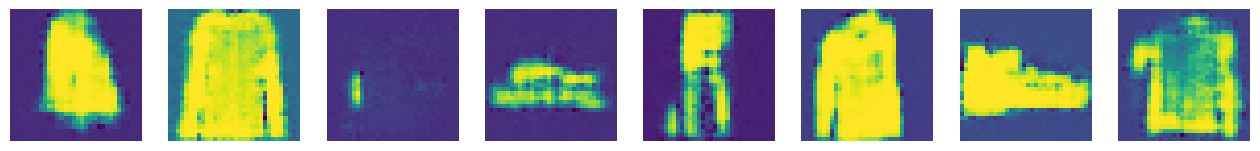

  0%|          | 0/1875 [00:00<?, ?it/s]

[Epoch: 8/10] [D loss: 0.0682] [G loss: 4.6005]


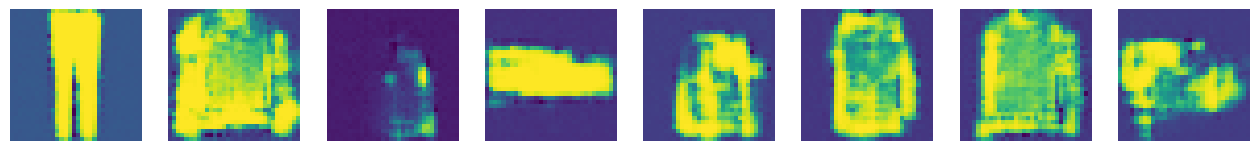

  0%|          | 0/1875 [00:00<?, ?it/s]

[Epoch: 9/10] [D loss: 0.0668] [G loss: 4.6246]


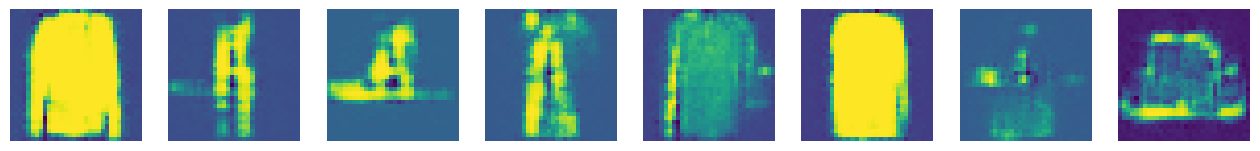

  0%|          | 0/1875 [00:00<?, ?it/s]

[Epoch: 10/10] [D loss: 0.0611] [G loss: 4.8042]


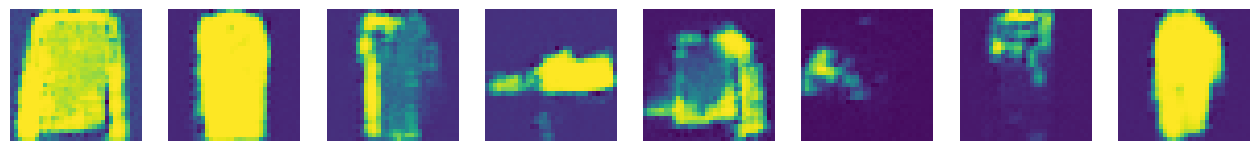

In [51]:
gan = GANManager()
gan_history = gan.train(dataloader)

## 